# kNN Classification — Credit Card Fraud Dataset

This notebook applies the k-Nearest Neighbours classifier to the Credit Card Fraud dataset. The aim is to classify transactions as normal or fraudulent.

Since the dataset is highly imbalanced, the model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrix analysis.

In [3]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
# =====================================================
# 2. LOAD CREDIT CARD DATASET
# =====================================================

credit = pd.read_csv("../dataset/creditcard.csv")

print("Original Credit Card Dataset Shape:", credit.shape)

display(credit.head())

Original Credit Card Dataset Shape: (16819, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# =====================================================
# 3. CREDIT CARD DATA CLEANING
# =====================================================

credit_clean = credit.copy()

original_shape = credit_clean.shape

# Remove duplicate rows
credit_clean = credit_clean.drop_duplicates()

# Remove missing values if any
credit_clean = credit_clean.dropna()

# Ensure target column is integer
credit_clean["Class"] = credit_clean["Class"].astype(int)

# Reset index
credit_clean = credit_clean.reset_index(drop=True)

print("Original Shape:", original_shape)
print("Cleaned Shape:", credit_clean.shape)

print("\nMissing Values After Cleaning:")
display(pd.DataFrame({"Missing Values": credit_clean.isnull().sum()}))

print("Duplicate Rows After Cleaning:", credit_clean.duplicated().sum())

display(credit_clean.head())

Original Shape: (16819, 31)
Cleaned Shape: (16764, 31)

Missing Values After Cleaning:


,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Duplicate Rows After Cleaning: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Class,Count,Percentage
0,Normal Transaction,16689,99.553
1,Fraud Transaction,75,0.447


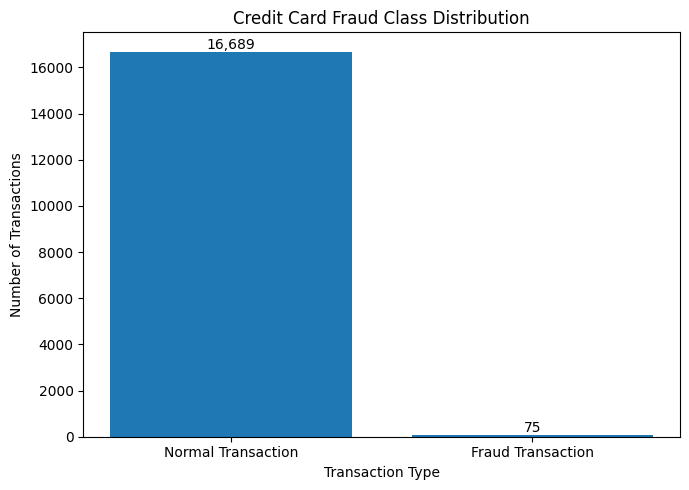

In [6]:
# =====================================================
# 4. CLASS IMBALANCE CHECK
# =====================================================

class_counts = credit_clean["Class"].value_counts().sort_index()
class_percentages = credit_clean["Class"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Class": ["Normal Transaction", "Fraud Transaction"],
    "Count": class_counts.values,
    "Percentage": class_percentages.round(3).values
})

display(class_distribution)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Class Imbalance Observation

The Credit Card Fraud dataset is highly imbalanced. Normal transactions make up the vast majority of the dataset, while fraudulent transactions are very rare.

Because of this imbalance, Accuracy alone is not sufficient to evaluate the model. A model could achieve very high Accuracy simply by predicting most transactions as normal, while still missing many fraud cases.

Therefore, Precision, Recall, F1-score, ROC-AUC, and the confusion matrix are used to evaluate the kNN model more fairly.

In [7]:
# =====================================================
# 5. FEATURE SCALING AND TRAIN-TEST SPLIT
# =====================================================

credit_scaled = credit_clean.copy()

scaler_credit = StandardScaler()

# Scale Time and Amount because they are not PCA-transformed like V1-V28
credit_scaled[["Time", "Amount"]] = scaler_credit.fit_transform(
    credit_scaled[["Time", "Amount"]]
)

X_credit = credit_scaled.drop(columns=["Class"])
y_credit = credit_scaled["Class"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit,
    y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

print("Credit Training Shape:", X_train_c.shape)
print("Credit Testing Shape:", X_test_c.shape)

print("\nTraining Target Distribution:")
display(y_train_c.value_counts(normalize=True).round(4).to_frame("Proportion"))

print("\nTesting Target Distribution:")
display(y_test_c.value_counts(normalize=True).round(4).to_frame("Proportion"))

Credit Training Shape: (13411, 30)
Credit Testing Shape: (3353, 30)

Training Target Distribution:


,Proportion
Class,
0,0.9955
1,0.0045



Testing Target Distribution:


,Proportion
Class,
0,0.9955
1,0.0045


In [8]:
# =====================================================
# 6. SAMPLE TRAINING DATA FOR kNN SPEED
# =====================================================

train_sample = pd.concat(
    [X_train_c, y_train_c],
    axis=1
).sample(
    n=min(50000, len(X_train_c)),
    random_state=42
)

X_train_sample = train_sample.drop(columns=["Class"])
y_train_sample = train_sample["Class"]

print("Sample Training Shape:", X_train_sample.shape)

print("\nSample Target Distribution:")
display(y_train_sample.value_counts().to_frame("Count"))

Sample Training Shape: (13411, 30)

Sample Target Distribution:


,Count
Class,
0,13351
1,60


In [9]:
# =====================================================
# 7. TRAIN kNN MODEL
# =====================================================

knn_credit = KNeighborsClassifier(
    n_neighbors=5
)

knn_credit.fit(
    X_train_sample,
    y_train_sample
)

knn_credit_pred = knn_credit.predict(
    X_test_c
)

knn_credit_prob = knn_credit.predict_proba(
    X_test_c
)[:, 1]

print("kNN Credit Card Classification Report:")

print(
    classification_report(
        y_test_c,
        knn_credit_pred,
        zero_division=0
    )
)

kNN Credit Card Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3338
           1       1.00      0.80      0.89        15

    accuracy                           1.00      3353
   macro avg       1.00      0.90      0.94      3353
weighted avg       1.00      1.00      1.00      3353



In [10]:
# =====================================================
# 8. kNN CREDIT PERFORMANCE METRICS
# =====================================================

knn_credit_results = pd.DataFrame({
    "Dataset": ["Credit Card Fraud"],
    "Model": ["kNN"],
    "Accuracy": [accuracy_score(y_test_c, knn_credit_pred)],
    "Precision": [precision_score(y_test_c, knn_credit_pred, zero_division=0)],
    "Recall": [recall_score(y_test_c, knn_credit_pred, zero_division=0)],
    "F1 Score": [f1_score(y_test_c, knn_credit_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_c, knn_credit_prob)]
})

display(knn_credit_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Credit Card Fraud,kNN,0.999,1.0,0.8,0.889,0.967


In [11]:
# =====================================================
# 9. TRAIN VS TEST PERFORMANCE CHECK
# =====================================================

knn_credit_train_pred = knn_credit.predict(X_train_sample)

train_test_comparison = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [
        accuracy_score(y_train_sample, knn_credit_train_pred),
        accuracy_score(y_test_c, knn_credit_pred)
    ],
    "Precision": [
        precision_score(y_train_sample, knn_credit_train_pred, zero_division=0),
        precision_score(y_test_c, knn_credit_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_train_sample, knn_credit_train_pred, zero_division=0),
        recall_score(y_test_c, knn_credit_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_train_sample, knn_credit_train_pred, zero_division=0),
        f1_score(y_test_c, knn_credit_pred, zero_division=0)
    ]
})

display(train_test_comparison.round(3))

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Training Data,0.999,0.96,0.8,0.873
1,Testing Data,0.999,1.00,0.8,0.889


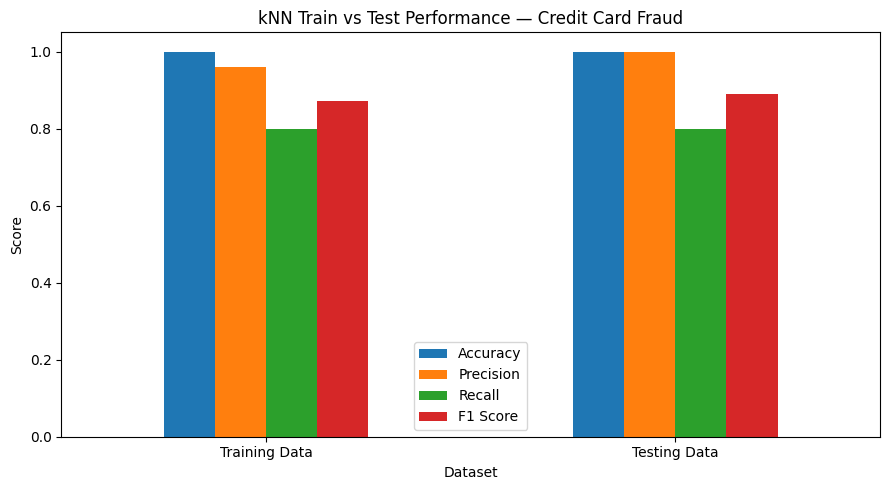

In [12]:
# =====================================================
# 10. TRAIN VS TEST PERFORMANCE VISUALISATION
# =====================================================

train_test_comparison.set_index("Dataset").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("kNN Train vs Test Performance — Credit Card Fraud")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

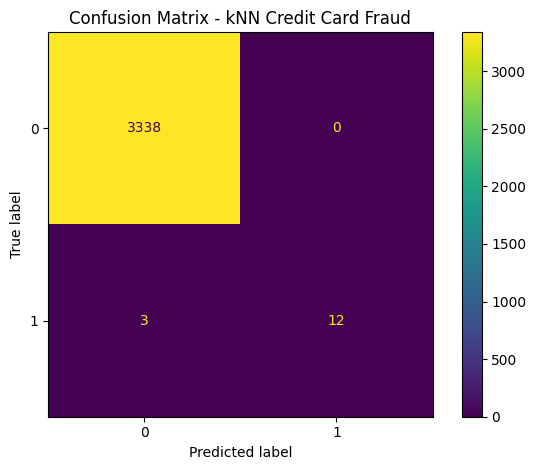

In [13]:
# =====================================================
# 11. CONFUSION MATRIX
# =====================================================

ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    knn_credit_pred
)

plt.title("Confusion Matrix - kNN Credit Card Fraud")
plt.tight_layout()
plt.show()

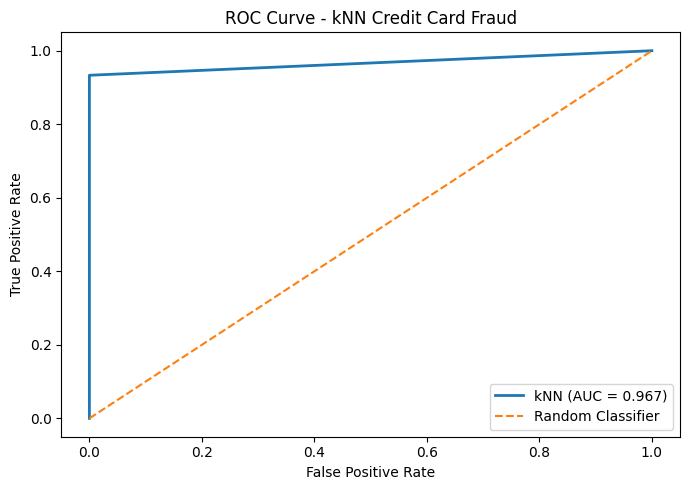

In [14]:
# =====================================================
# 12. ROC CURVE
# =====================================================

fpr, tpr, thresholds = roc_curve(
    y_test_c,
    knn_credit_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"kNN (AUC = {roc_auc_score(y_test_c, knn_credit_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - kNN Credit Card Fraud")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# =====================================================
# 13. SAVE kNN CREDIT RESULTS
# =====================================================

knn_credit_results.to_csv(
    "../results/Knn_credit_results.csv",
    index=False
)

print("kNN credit results saved successfully.")

from google.colab import files
files.download("../results/Knn_credit_results.csv")

kNN credit results saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## kNN Credit Card Summary

The kNN model was applied to the Credit Card Fraud dataset to classify transactions as normal or fraudulent.

Since kNN is distance-based, feature scaling was applied before training. Time and Amount were scaled using StandardScaler. A sample of 50,000 training records was used to reduce prediction runtime, as kNN compares every new record against all training examples.

The dataset was highly imbalanced, with normal transactions far outnumbering fraud cases. Because of this, Accuracy alone was not sufficient to evaluate performance. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix were used to understand how well the model detected fraud.

The model achieved high Accuracy and strong Precision, meaning that when it predicted fraud, it was usually correct. However, Recall was lower, meaning the model missed a portion of actual fraud cases. This is a common challenge when fraud examples are rare and underrepresented in the neighbourhood of new transactions.

The ROC-AUC score confirmed reasonable class separation ability. The confusion matrix helped identify the balance between false positives and false negatives.

Overall, kNN was a useful baseline for fraud detection, but its performance was limited by the class imbalance and the computational cost of distance-based prediction on large datasets.